# Proposed Hybrid Residual Model

## Architecture

This notebook implements the **Hybrid Residual Learning Framework** proposed as the project's main contribution:

$$\hat{X}_{final} = X_{physics} + f_{\theta}(X_{input},\, X_{physics})$$

where:
- $X_{physics}$ — inverse-distance weighted (IDW) interpolation prior (physics baseline)
- $f_{\theta}$ — **ResidualMLP**: a two-hidden-layer MLP trained to predict the residual error $\epsilon = X_{true} - X_{physics}$

**Why residual learning?**
The model only needs to learn *corrections* to the physics prior, which is already a strong estimate. This reduces the learning problem, accelerates convergence, and guarantees the output degrades gracefully to the physics prior when the network has insufficient information.

## Notebook Flow
1. Setup: paths, constants, helper functions.
2. ResidualMLP architecture and training utilities.
3. LOSO (Leave-One-Subject-Out) training and evaluation.
4. Export: CSV, JSON summary, comparison PNG.

In [1]:
# ── 1. Imports and path discovery ─────────────────────────────────────────────
# Centralises all dependencies; keeps remaining cells method-focused.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def find_repo_root(start: Path) -> Path:
    """Locate repository root by scanning parent directories."""
    for p in [start, *start.parents]:
        if (p / 'Main_codes').exists():
            return p
    raise RuntimeError('Cannot locate repository root.')


REPO_ROOT     = find_repo_root(Path.cwd().resolve())
NOTEBOOK_DIR  = REPO_ROOT / 'Main_codes' / 'Proposed_Hybrid_Model'
PROCESSED_DIR = REPO_ROOT / 'processed' / 'bci_competition_iv_2a'
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Channel definitions ────────────────────────────────────────────────────────
CHANNELS_22 = [
    'Fz',  'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5',  'C3',  'C1',  'Cz',  'C2',  'C4',  'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1',  'Pz',  'P2',  'POz'
]
CHANNEL_POS_2D = {
    'Fz':  ( 0.00,  0.62), 'FC3': (-0.33,  0.34), 'FC1': (-0.14,  0.34),
    'FCz': ( 0.00,  0.32), 'FC2': ( 0.14,  0.34), 'FC4': ( 0.33,  0.34),
    'C5':  (-0.50,  0.00), 'C3':  (-0.33,  0.00), 'C1':  (-0.14,  0.00),
    'Cz':  ( 0.00,  0.00), 'C2':  ( 0.14,  0.00), 'C4':  ( 0.33,  0.00),
    'C6':  ( 0.50,  0.00), 'CP3': (-0.33, -0.30), 'CP1': (-0.14, -0.30),
    'CPz': ( 0.00, -0.30), 'CP2': ( 0.14, -0.30), 'CP4': ( 0.33, -0.30),
    'P1':  (-0.14, -0.52), 'Pz':  ( 0.00, -0.54), 'P2':  ( 0.14, -0.52),
    'POz': ( 0.00, -0.82)
}
CHANNEL_SET_5  = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz',
                  'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']

# ── Utility helpers ────────────────────────────────────────────────────────────
def load_subject(subject_dir: Path):
    """Load one subject's preprocessed EEG trials (NPZ)."""
    npz = np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)


def to_sample_matrix(trials):
    """Reshape (trials, channels, time) -> (trials*time, channels)."""
    n, c, t = trials.shape
    return np.transpose(trials, (0, 2, 1)).reshape(n * t, c)


def idw_interpolate(X_input, input_chs, target_chs, eps: float = 1e-8):
    """Inverse-distance weighted interpolation (physics prior)."""
    in_pos = np.array([CHANNEL_POS_2D[c] for c in input_chs], dtype=np.float32)
    out = []
    for ch in target_chs:
        tp = np.array(CHANNEL_POS_2D[ch], dtype=np.float32)
        d  = np.linalg.norm(in_pos - tp[None, :], axis=1)
        w  = 1.0 / (d + eps)
        w  = w / w.sum()
        out.append((X_input * w[None, :]).sum(axis=1))
    return np.stack(out, axis=1)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute RMSE, MAE, Pearson r, and R² reconstruction metrics."""
    diff = y_true - y_pred
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae  = float(np.mean(np.abs(diff)))
    yt, yp   = y_true.ravel(), y_pred.ravel()
    yc, pc   = yt - yt.mean(), yp - yp.mean()
    den      = np.sqrt((yc ** 2).sum() * (pc ** 2).sum())
    pearsonr = float((yc * pc).sum() / den) if den > 0 else float('nan')
    ss_res   = float(((yt - yp) ** 2).sum())
    ss_tot   = float(((yt - yt.mean()) ** 2).sum())
    r2       = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearsonr, 'r2': r2}


RNG         = np.random.default_rng(42)
MAX_SPLITS  = 0          # 0 = use all LOSO splits
MAX_TRAIN   = 200_000    # subsample cap to keep training time reasonable
loso_splits = json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))
if MAX_SPLITS > 0:
    loso_splits = loso_splits[:MAX_SPLITS]

print(f'Device : {DEVICE}')
print(f'LOSO splits : {len(loso_splits)}')
print(f'Processed dir : {PROCESSED_DIR}')

Device : cpu
LOSO splits : 9
Processed dir : E:\Github\EEGFeatureExtraction\processed\bci_competition_iv_2a


## 2. ResidualMLP Architecture

**Input** : `concat([X_input, X_physics])` — shape `(N, n_input_ch + n_missing_ch)`

**Output** : residual $\epsilon$ — shape `(N, n_missing_ch)`

**Stack**:
```
Linear(n_in → 512) → BatchNorm → ReLU → Dropout(0.2)
Linear(512 → 256)  → BatchNorm → ReLU → Dropout(0.2)
Linear(256 → n_out)
```

**Training**: Adam (lr=1e-3, weight_decay=1e-5) + CosineAnnealingLR + gradient clipping (norm=1.0)

At inference: `y_final = X_physics + MLP([X_input | X_physics])`

In [2]:
# ── 2. ResidualMLP definition and training utilities ──────────────────────────

class ResidualMLP(nn.Module):
    """
    Two-hidden-layer MLP that predicts the residual between the physics prior
    and the ground-truth signal.

    Input  : concat([X_raw_input, X_physics_prior])
    Output : residual epsilon  (same size as number of missing channels)
    """

    def __init__(self, n_input: int, n_output: int,
                 hidden: int = 512, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_output),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train_mlp(model: nn.Module, x_train: np.ndarray, y_train: np.ndarray,
              epochs: int = 20, batch_size: int = 512,
              lr: float = 1e-3, val_frac: float = 0.1) -> nn.Module:
    """Train the MLP with Adam + CosineAnnealingLR + gradient clipping."""
    xt = torch.tensor(x_train, dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32)
    n  = xt.shape[0]
    nv = max(1, int(n * val_frac))
    perm = torch.randperm(n)
    vi, ti = perm[:nv], perm[nv:]
    if ti.numel() == 0:
        ti = vi

    tr_dl = DataLoader(TensorDataset(xt[ti], yt[ti]),
                       batch_size=batch_size, shuffle=True)
    vl_dl = DataLoader(TensorDataset(xt[vi], yt[vi]),
                       batch_size=batch_size, shuffle=False)

    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sch    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()
    model.to(DEVICE)

    for epoch in range(1, epochs + 1):
        model.train()
        tl = tc = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item() * xb.shape[0]
            tc += xb.shape[0]
        sch.step()

        model.eval()
        vl = vc = 0
        with torch.no_grad():
            for xb, yb in vl_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = loss_fn(model(xb), yb)
                vl += loss.item() * xb.shape[0]
                vc += xb.shape[0]

        print(f'Epoch {epoch:02d}/{epochs}  '
              f'train_loss={tl/tc:.5f}  val_loss={vl/vc:.5f}')

    return model


def predict_mlp(model: nn.Module, x: np.ndarray) -> np.ndarray:
    """Run model inference and return numpy array."""
    model.eval()
    with torch.no_grad():
        return model(
            torch.tensor(x, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()


print('ResidualMLP architecture defined.')

ResidualMLP architecture defined.


## 3. LOSO Training and Evaluation

For each leave-one-subject-out split and each input channel set (5 / 10 / 15 channels):

| Step | Description |
|------|-------------|
| 1 | Compute IDW physics prior on training samples |
| 2 | Residual target = ground truth − physics prior |
| 3 | Train ResidualMLP on `[X_input \| X_physics]` → residual |
| 4 | Test: `y_final = X_physics_test + MLP(feat_test)` |
| 5 | Record metrics for **IDW baseline** and **Hybrid MLP** |

Metrics: RMSE ↓, MAE ↓, Pearson r ↑, R² ↑

In [3]:
# ── 3. LOSO loop ───────────────────────────────────────────────────────────────

rows = []

for split in loso_splits:
    test_subj   = split['test_subject']
    train_subjs = split['train_subjects']

    # Build training matrix
    blocks = [
        to_sample_matrix(load_subject(PROCESSED_DIR / s)[0])
        for s in train_subjs
    ]
    train_mat = np.concatenate(blocks, axis=0)
    if MAX_TRAIN > 0 and train_mat.shape[0] > MAX_TRAIN:
        idx = RNG.choice(train_mat.shape[0], MAX_TRAIN, replace=False)
        train_mat = train_mat[idx]

    # Build test matrix (full — no subsampling at test time)
    test_mat = to_sample_matrix(load_subject(PROCESSED_DIR / test_subj)[0])

    for in_chs in [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]:
        in_idx   = [CHANNELS_22.index(c) for c in in_chs]
        miss_chs = [c for c in CHANNELS_22 if c not in in_chs]
        mis_idx  = [CHANNELS_22.index(c) for c in miss_chs]

        # Raw slices
        x_tr_in = train_mat[:, in_idx]
        y_tr     = train_mat[:, mis_idx]
        x_te_in = test_mat[:, in_idx]
        y_te     = test_mat[:, mis_idx]

        # Physics prior (IDW)
        p_tr = idw_interpolate(x_tr_in, in_chs, miss_chs)
        p_te = idw_interpolate(x_te_in, in_chs, miss_chs)

        # Residual target for training
        res_tr = y_tr - p_tr

        # Feature = [X_input | X_physics]
        feat_tr = np.concatenate([x_tr_in, p_tr], axis=1)
        feat_te = np.concatenate([x_te_in, p_te], axis=1)

        # Train ResidualMLP
        mlp = ResidualMLP(n_input=feat_tr.shape[1], n_output=res_tr.shape[1])
        mlp = train_mlp(mlp, feat_tr, res_tr)

        # Inference: hybrid = physics prior + predicted residual
        res_pred = predict_mlp(mlp, feat_te)
        y_hybrid = p_te + res_pred

        base_row = dict(
            test_subject=test_subj,
            n_input_channels=len(in_chs),
            input_channels=','.join(in_chs),
            n_reconstructed_channels=len(miss_chs),
            n_test_samples=int(test_mat.shape[0]),
        )

        rows.append({**base_row, 'method': 'idw_interpolation',
                     **compute_metrics(y_te, p_te)})
        rows.append({**base_row, 'method': 'hybrid_residual_mlp',
                     **compute_metrics(y_te, y_hybrid)})

df = pd.DataFrame(rows)
df.head(10)

Epoch 01/20  train_loss=6.74108  val_loss=6.36936
Epoch 02/20  train_loss=6.48120  val_loss=6.34723
Epoch 03/20  train_loss=6.45413  val_loss=6.36811
Epoch 04/20  train_loss=6.44748  val_loss=6.33018
Epoch 05/20  train_loss=6.43409  val_loss=6.33542
Epoch 06/20  train_loss=6.42251  val_loss=6.33965
Epoch 07/20  train_loss=6.42014  val_loss=6.32596
Epoch 08/20  train_loss=6.41380  val_loss=6.31318
Epoch 09/20  train_loss=6.40708  val_loss=6.31799
Epoch 10/20  train_loss=6.39985  val_loss=6.29902
Epoch 11/20  train_loss=6.39245  val_loss=6.30608
Epoch 12/20  train_loss=6.38326  val_loss=6.29359
Epoch 13/20  train_loss=6.38127  val_loss=6.29864
Epoch 14/20  train_loss=6.37641  val_loss=6.28904
Epoch 15/20  train_loss=6.37457  val_loss=6.28796
Epoch 16/20  train_loss=6.36814  val_loss=6.28915
Epoch 17/20  train_loss=6.36401  val_loss=6.28638
Epoch 18/20  train_loss=6.36412  val_loss=6.28647
Epoch 19/20  train_loss=6.35964  val_loss=6.28140
Epoch 20/20  train_loss=6.36066  val_loss=6.28170


,test_subject,n_input_channels,input_channels,n_reconstructed_channels,n_test_samples,method,rmse,mae,pearson_r,r2
0,A01T,5,"Fz,C3,C4,Pz,POz",17,273000,idw_interpolation,3.305309,2.570899,0.945703,0.892169
1,A01T,5,"Fz,C3,C4,Pz,POz",17,273000,hybrid_residual_mlp,2.266039,1.747216,0.974366,0.949318
2,A01T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,273000,idw_interpolation,3.103805,2.393991,0.951523,0.904474
3,A01T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,273000,hybrid_residual_mlp,1.805809,1.366654,0.983701,0.967665
4,A01T,15,"Fz,FC3,FC1,FC2,FC4,C3,C1,Cz,C2,C4,CP3,CP1,CP2,...",7,273000,idw_interpolation,4.268795,3.258233,0.901412,0.805404
5,A01T,15,"Fz,FC3,FC1,FC2,FC4,C3,C1,Cz,C2,C4,CP3,CP1,CP2,...",7,273000,hybrid_residual_mlp,1.965222,1.481218,0.979175,0.958757
6,A02T,5,"Fz,C3,C4,Pz,POz",17,270000,idw_interpolation,2.786402,2.107620,0.949558,0.899489
7,A02T,5,"Fz,C3,C4,Pz,POz",17,270000,hybrid_residual_mlp,2.123140,1.573375,0.970406,0.941645
8,A02T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,270000,idw_interpolation,2.772241,2.064081,0.949480,0.900787
9,A02T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,270000,hybrid_residual_mlp,1.872186,1.315513,0.977115,0.954752


## 4. Export Metrics and Visualisations

Saves:
- `hybrid_residual_metrics.csv` — full per-subject, per-channel-set results
- `hybrid_residual_summary.json` — mean metrics aggregated by input channel count
- `hybrid_residual_metrics_plot.png` — side-by-side comparison of IDW vs Hybrid MLP

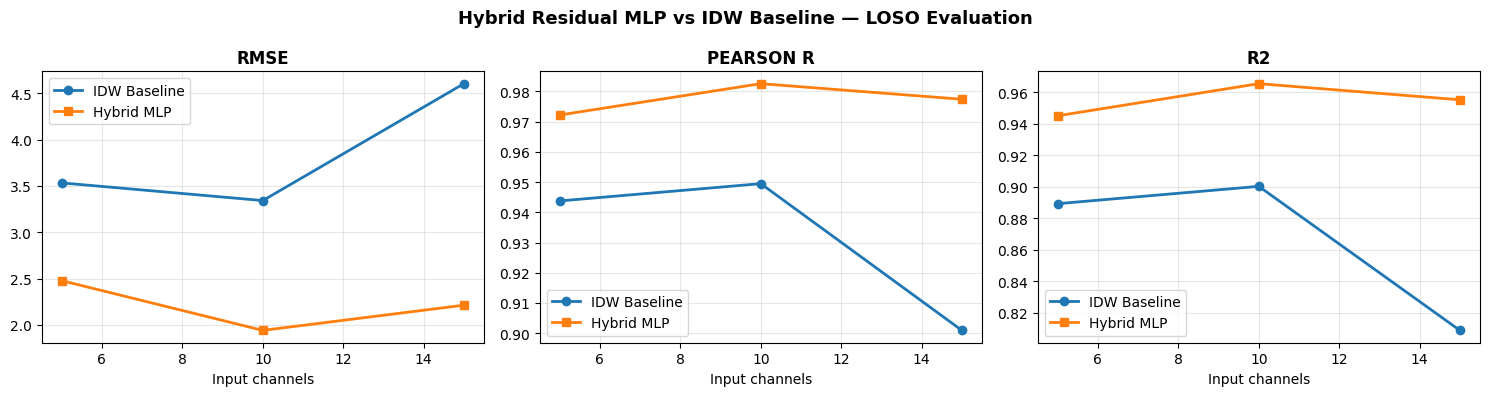

Saved: E:\Github\EEGFeatureExtraction\Main_codes\Proposed_Hybrid_Model\hybrid_residual_metrics.csv
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Proposed_Hybrid_Model\hybrid_residual_summary.json
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Proposed_Hybrid_Model\hybrid_residual_metrics_plot.png

=== Mean Metrics by Input Channel Count ===
                                        rmse     mae  pearson_r      r2
n_input_channels method                                                
5                hybrid_residual_mlp  2.4772  1.8949     0.9722  0.9450
                 idw_interpolation    3.5321  2.7216     0.9438  0.8893
10               hybrid_residual_mlp  1.9404  1.4467     0.9826  0.9654
                 idw_interpolation    3.3413  2.5579     0.9495  0.9003
15               hybrid_residual_mlp  2.2123  1.6232     0.9774  0.9552
                 idw_interpolation    4.6028  3.4606     0.9009  0.8090


In [4]:
# ── 4. Export ─────────────────────────────────────────────────────────────────

out_csv  = NOTEBOOK_DIR / 'hybrid_residual_metrics.csv'
out_json = NOTEBOOK_DIR / 'hybrid_residual_summary.json'
out_png  = NOTEBOOK_DIR / 'hybrid_residual_metrics_plot.png'

df.to_csv(out_csv, index=False)

summary = (
    df[df['method'] == 'hybrid_residual_mlp']
    .groupby('n_input_channels', as_index=False)
    [['rmse', 'mae', 'pearson_r', 'r2']]
    .mean()
)
payload = {
    'rows':         int(len(df)),
    'splits':       int(len(loso_splits)),
    'method':       'hybrid_residual_mlp',
    'device':       DEVICE,
    'architecture': 'ResidualMLP(input → 512 → 256 → output)',
    'mean_metrics': summary.to_dict(orient='records'),
}
out_json.write_text(json.dumps(payload, indent=2), encoding='utf-8')

# ── Comparison plot ────────────────────────────────────────────────────────────
PLOT_METRICS = ['rmse', 'pearson_r', 'r2']
METHODS = [
    ('idw_interpolation',  'IDW Baseline', 'tab:blue',   'o'),
    ('hybrid_residual_mlp','Hybrid MLP',   'tab:orange', 's'),
]

fig, axes = plt.subplots(1, len(PLOT_METRICS), figsize=(15, 4))

for ax, met in zip(axes, PLOT_METRICS):
    for method, label, color, marker in METHODS:
        sub = (
            df[df['method'] == method]
            .groupby('n_input_channels', as_index=False)[met]
            .mean()
        )
        ax.plot(sub['n_input_channels'], sub[met],
                marker=marker, color=color, label=label, linewidth=2)
    ax.set_title(met.replace('_', ' ').upper(), fontweight='bold')
    ax.set_xlabel('Input channels')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Hybrid Residual MLP vs IDW Baseline — LOSO Evaluation',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(out_png, dpi=150)
plt.show()

print(f'Saved: {out_csv}')
print(f'Saved: {out_json}')
print(f'Saved: {out_png}')

# ── Quick summary table ────────────────────────────────────────────────────────
print('\n=== Mean Metrics by Input Channel Count ===')
pivot = (
    df.groupby(['n_input_channels', 'method'])
    [['rmse', 'mae', 'pearson_r', 'r2']]
    .mean()
    .round(4)
)
print(pivot.to_string())